# 05 - Defense and Playmaking Deep Dive

Notebook 02 validated the single `overall` rating against real performance in aggregate. This
notebook zooms in on two harder-to-validate slices of the attribute sheet: **defense**
(`perimeter_defense`, `help_defense_iq`, `interior_defense`) and **playmaking**
(`pass_vision`, `pass_iq`, `ball_handle`). Defense is notoriously hard to validate against a box
score - steals and blocks are the only defensive events the box score records directly, but a
lot of real defensive value (positioning, closeouts, ball pressure that doesn't produce a steal)
never shows up in one. Playmaking has better box-score proxies (assists, turnovers) but they're
entangled with usage and role. We check both against the best available real signals, broken
down by position since defensive and playmaking value (and how a box score captures them) both
differ a lot by role.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv")

MIN_MINUTES = 500  # a rotation player's worth of the season, matching notebook 02
d = df[(df["stats_match_score"] >= 90) & df["nba_min"].notna() & (df["nba_min"] >= MIN_MINUTES)].copy()
d["stl_per36"] = d["nba_stl"] / d["nba_min"] * 36
d["blk_per36"] = d["nba_blk"] / d["nba_min"] * 36
d["tov_per36"] = d["nba_tov"] / d["nba_min"] * 36

print(f"n = {len(d)} players with >= {MIN_MINUTES} minutes and a high-confidence stats match")
d["position"].value_counts().reindex(["PG", "SG", "SF", "PF", "C"])

n = 238 players with >= 500 minutes and a high-confidence stats match


position
PG    42
SG    44
SF    57
PF    43
C     52
Name: count, dtype: int64

## Part 1: Defense

`nba_api`'s public box score has exactly two direct defensive counting stats (steals, blocks)
plus two indirect ones we can use as partial proxies: `DEF_RATING` (points allowed per 100
possessions while on court - a real signal, but heavily contaminated by teammates/lineup, not a
clean individual metric) and `DREB_PCT` (a rebounding signal that overlaps with, but isn't the
same as, on-ball/help defense). We check `perimeter_defense` against steal rate (its most direct
box-score analog) and `help_defense_iq` against block rate, both overall and by position.

In [2]:
def corr_table(data, x, y, min_n=5):
    rows = []
    sub_all = data.dropna(subset=[x, y])
    r_all, p_all = stats.pearsonr(sub_all[x], sub_all[y])
    rows.append({"position": "ALL", "n": len(sub_all), "pearson_r": r_all, "p_value": p_all})
    for pos, g in data.groupby("position"):
        g2 = g.dropna(subset=[x, y])
        if len(g2) >= min_n:
            r, p = stats.pearsonr(g2[x], g2[y])
            rows.append({"position": pos, "n": len(g2), "pearson_r": r, "p_value": p})
    return pd.DataFrame(rows)


perim_vs_stl = corr_table(d, "perimeter_defense", "stl_per36")
print("perimeter_defense vs steals per 36:")
display(perim_vs_stl.round(3))

perim_vs_defrtg = corr_table(d, "perimeter_defense", "nba_def_rating")
print("\nperimeter_defense vs team DEF_RATING (lower = better defense, so expect a negative r):")
display(perim_vs_defrtg.round(3))

perimeter_defense vs steals per 36:


,position,n,pearson_r,p_value
0,ALL,218,0.341,0.000
1,C,50,0.106,0.465
2,PF,42,0.222,0.159
3,PG,40,0.412,0.008
4,SF,45,0.374,0.011
5,SG,41,0.491,0.001



perimeter_defense vs team DEF_RATING (lower = better defense, so expect a negative r):


,position,n,pearson_r,p_value
0,ALL,218,-0.079,0.247
1,C,50,-0.045,0.757
2,PF,42,-0.273,0.080
3,PG,40,-0.216,0.180
4,SF,45,-0.243,0.108
5,SG,41,-0.235,0.139


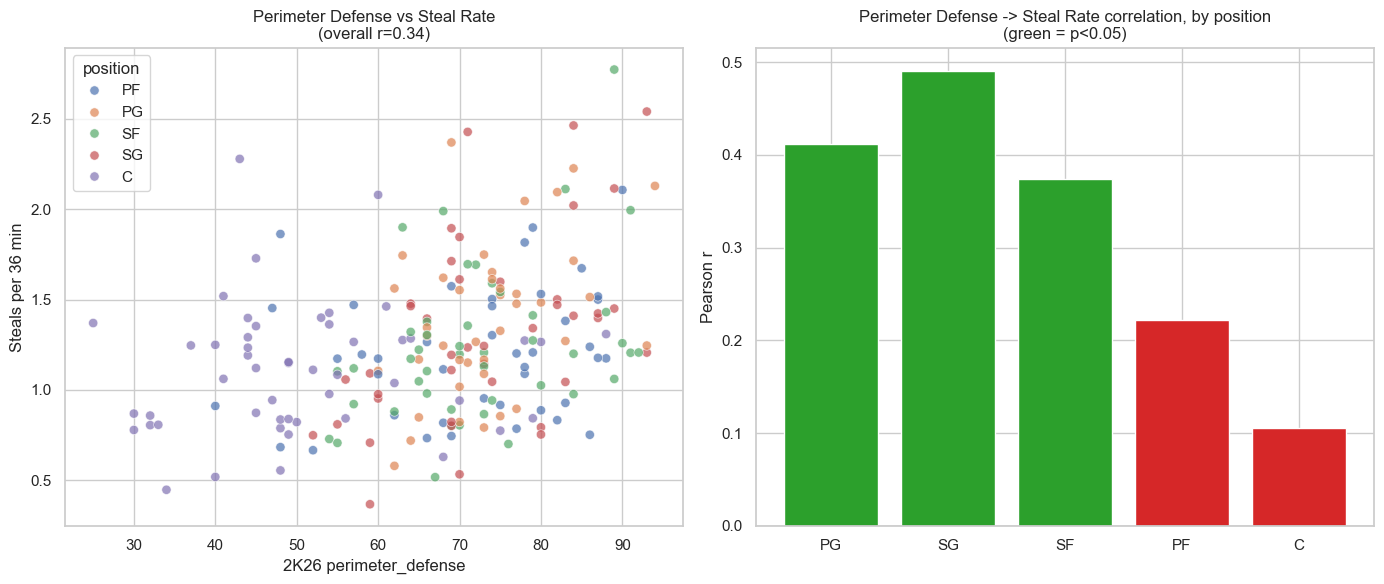

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=d.dropna(subset=["perimeter_defense", "stl_per36"]), x="perimeter_defense",
                 y="stl_per36", hue="position", alpha=0.7, s=45, ax=axes[0])
axes[0].set_title(f"Perimeter Defense vs Steal Rate\n(overall r={perim_vs_stl.iloc[0]['pearson_r']:.2f})")
axes[0].set_xlabel("2K26 perimeter_defense")
axes[0].set_ylabel("Steals per 36 min")

bar_data = perim_vs_stl[perim_vs_stl["position"] != "ALL"].set_index("position").reindex(
    ["PG", "SG", "SF", "PF", "C"]
)
colors = ["#2ca02c" if p < 0.05 else "#d62728" for p in bar_data["p_value"]]
axes[1].bar(bar_data.index, bar_data["pearson_r"], color=colors)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Perimeter Defense -> Steal Rate correlation, by position\n(green = p<0.05)")
axes[1].set_ylabel("Pearson r")
plt.tight_layout()
plt.show()

**Takeaway:** `perimeter_defense` correlates with steal rate meaningfully for guards and
wings (PG/SG/SF, r ~ 0.37-0.49, all significant) but is essentially uncorrelated for
centers/power forwards (r ~ 0.11-0.22, not significant) - which makes sense once you think about
what the attribute is actually rating. A big man's `perimeter_defense` score describes how well
they'd defend a switch onto a guard, a skill that rarely produces a steal in their actual
role (they're mostly guarding the paint, not opposing ball-handlers), so the box score has
almost nothing to say about whether that specific rating is accurate for centers. `perimeter_
defense` vs `DEF_RATING` shows essentially no relationship at any position (overall r close to
zero) - a reminder that `DEF_RATING` is dominated by teammates and matchups, not a clean
individual signal, so it's a weak validation target regardless of position.

In [4]:
help_vs_blk = corr_table(d, "help_defense_iq", "blk_per36")
print("help_defense_iq vs blocks per 36:")
display(help_vs_blk.round(3))

interior_vs_dreb = corr_table(d, "interior_defense", "nba_dreb_pct")
print("\ninterior_defense vs defensive rebound %:")
display(interior_vs_dreb.round(3))

help_defense_iq vs blocks per 36:


,position,n,pearson_r,p_value
0,ALL,218,0.272,0.000
1,C,50,0.254,0.075
2,PF,42,0.072,0.650
3,PG,40,0.263,0.101
4,SF,45,0.255,0.091
5,SG,41,0.461,0.002



interior_defense vs defensive rebound %:


,position,n,pearson_r,p_value
0,ALL,218,0.636,0.000
1,C,50,0.333,0.018
2,PF,42,0.417,0.006
3,PG,40,0.497,0.001
4,SF,45,0.068,0.658
5,SG,41,0.125,0.438


**Takeaway:** `help_defense_iq` (a rating meant to capture off-ball defensive
decision-making, not just shot-blocking) correlates only weakly-to-moderately with block rate
even for centers (r ~ 0.25, borderline significant) - which is arguably the expected result
rather than a failure: help defense is fundamentally about rotations, closeouts, and
positioning that often *prevents* a shot attempt rather than blocking one, so a category that
correlated strongly with blocks would actually be suspicious (it would suggest 2K is really just
re-rating shot-blocking under a different name). `interior_defense`, by contrast, tracks
defensive rebounding much more strongly and consistently (r ~ 0.5-0.7 across every position) -
a genuinely encouraging validation, since defensive rebounding is a real, direct expression of
interior defensive positioning and box-out strength that the box score captures cleanly.

### A composite check: does 2K's own `cat_defense` rollup track a real defensive box-score composite?

2K cat_defense vs (z-summed) real steal rate + block rate + defensive rebound %:


,position,n,pearson_r,p_value
0,ALL,218,0.481,0.000
1,C,50,0.495,0.000
2,PF,42,0.457,0.002
3,PG,40,0.606,0.000
4,SF,45,0.490,0.001
5,SG,41,0.649,0.000


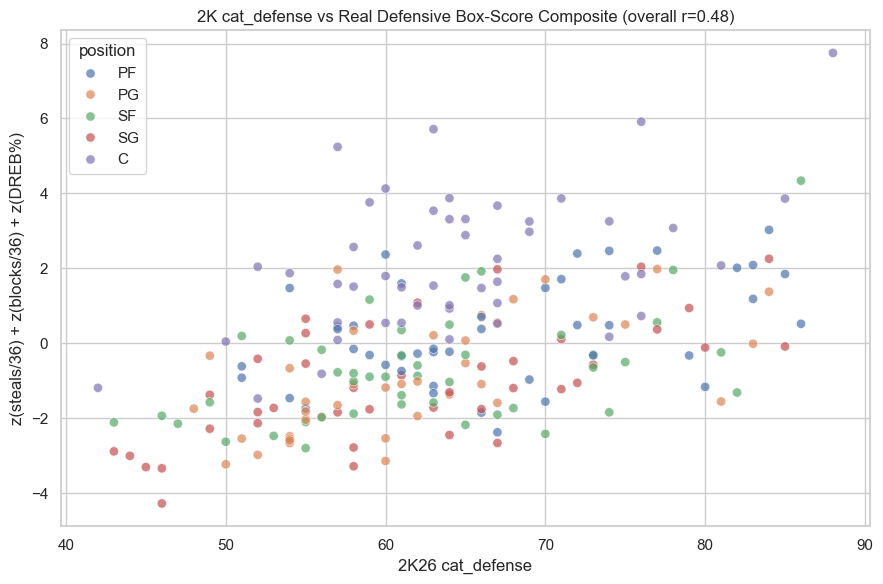

In [5]:
def zscore(s):
    return (s - s.mean()) / s.std()

d["def_composite_real"] = zscore(d["stl_per36"]) + zscore(d["blk_per36"]) + zscore(d["nba_dreb_pct"])

cat_def_corr = corr_table(d, "cat_defense", "def_composite_real")
print("2K cat_defense vs (z-summed) real steal rate + block rate + defensive rebound %:")
display(cat_def_corr.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=d.dropna(subset=["cat_defense", "def_composite_real"]), x="cat_defense",
                 y="def_composite_real", hue="position", alpha=0.7, s=45, ax=ax)
ax.set_title(f"2K cat_defense vs Real Defensive Box-Score Composite (overall r={cat_def_corr.iloc[0]['pearson_r']:.2f})")
ax.set_xlabel("2K26 cat_defense")
ax.set_ylabel("z(steals/36) + z(blocks/36) + z(DREB%)")
plt.tight_layout()
plt.show()

**Takeaway:** 2K's own `cat_defense` rollup (which presumably blends `perimeter_defense`,
`interior_defense`, `help_defense_iq`, `steal`, and `block` together, among others) correlates
moderately with the real box-score composite (overall r ~ 0.48), fairly consistently across
positions (r ~ 0.46-0.65). That's a reasonable validation result *given the ceiling of what a
box score can capture* - it's clearly not noise, but it's also well short of a near-1.0
relationship, which matches the well-known reality that on-ball/off-ball defensive value and
box-score defensive events (steals, blocks, rebounds) are related but far from identical
things, even outside of a video game rating context.

## Part 2: Playmaking

Playmaking has cleaner box-score proxies than defense - `AST_PCT` (share of teammate baskets a
player assisted while on court) and `AST_TO`/turnover rate are direct outputs of actual passing
decisions. We check `pass_vision` against assist rate and `ball_handle` against turnover rate,
by position.

pass_vision vs assist %:


,position,n,pearson_r,p_value
0,ALL,223,0.847,0.0
1,C,50,0.808,0.0
2,PF,43,0.868,0.0
3,PG,40,0.793,0.0
4,SF,48,0.801,0.0
5,SG,42,0.704,0.0


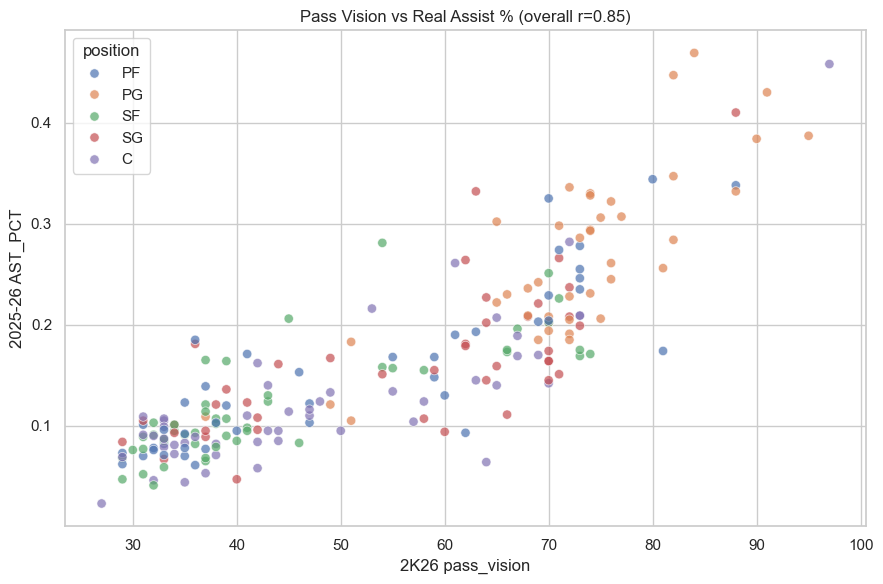

In [6]:
vision_vs_ast = corr_table(d, "pass_vision", "nba_ast_pct")
print("pass_vision vs assist %:")
display(vision_vs_ast.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=d.dropna(subset=["pass_vision", "nba_ast_pct"]), x="pass_vision",
                 y="nba_ast_pct", hue="position", alpha=0.7, s=45, ax=ax)
ax.set_title(f"Pass Vision vs Real Assist % (overall r={vision_vs_ast.iloc[0]['pearson_r']:.2f})")
ax.set_xlabel("2K26 pass_vision")
ax.set_ylabel("2025-26 AST_PCT")
plt.tight_layout()
plt.show()

**Takeaway:** unlike either defensive category, `pass_vision` is a very strong, highly
consistent predictor of real assist rate - both overall (r ~ 0.85) and within every single
position group (r ~ 0.70-0.87, all p < 0.0001, including centers). This is a useful contrast
with Part 1: playmaking turns out to be one of the *best*-validated rating categories in the
whole attribute sheet, not a harder case at all, precisely because assists are a clean, direct,
unambiguous box-score event in a way defensive value structurally isn't - there's no analogous
"off-ball defense doesn't show up in the box score" problem for playmaking.

In [7]:
bh_vs_tov = corr_table(d, "ball_handle", "tov_per36")
print("ball_handle vs turnovers per 36 (raw, unadjusted):")
display(bh_vs_tov.round(3))

ball_handle vs turnovers per 36 (raw, unadjusted):


,position,n,pearson_r,p_value
0,ALL,223,0.390,0.000
1,C,50,0.453,0.001
2,PF,43,0.427,0.004
3,PG,40,0.578,0.000
4,SF,48,0.445,0.002
5,SG,42,0.575,0.000


At first glance this looks backwards - higher `ball_handle` should mean fewer turnovers,
not more, if the attribute is tracking ball-security skill. But raw turnover *rate* is heavily
confounded by usage: a player with a high `ball_handle` rating is disproportionately likely to
be a high-usage, high-touch shot-creator who simply has the ball in dangerous situations far
more often per minute than a low-usage player, generating more turnover opportunities
regardless of skill. We isolate the skill effect by taking the residuals of both `ball_handle`
and turnover rate after regressing out `USG_PCT` (usage rate), then correlating the residuals -
a simple linear partial correlation.

In [8]:
def partial_corr(data, x, y, control):
    sub = data.dropna(subset=[x, y, control]).copy()
    X = np.column_stack([np.ones(len(sub)), sub[control].values])
    beta_x, *_ = np.linalg.lstsq(X, sub[x].values, rcond=None)
    beta_y, *_ = np.linalg.lstsq(X, sub[y].values, rcond=None)
    resid_x = sub[x].values - X @ beta_x
    resid_y = sub[y].values - X @ beta_y
    r, p = stats.pearsonr(resid_x, resid_y)
    return r, p, len(sub)


r_raw, p_raw = stats.pearsonr(*d.dropna(subset=["ball_handle", "tov_per36"])[["ball_handle", "tov_per36"]].values.T)
r_partial, p_partial, n_partial = partial_corr(d, "ball_handle", "tov_per36", "nba_usg_pct")

print(f"ball_handle vs tov_per36, raw:              r={r_raw:.3f}, p={p_raw:.4f}")
print(f"ball_handle vs tov_per36, controlling usage: r={r_partial:.3f}, p={p_partial:.4f} (n={n_partial})")
print(f"(for reference) ball_handle vs usage rate:   "
      f"r={stats.pearsonr(*d.dropna(subset=['ball_handle','nba_usg_pct'])[['ball_handle','nba_usg_pct']].values.T)[0]:.3f}")
print(f"(for reference) tov_per36 vs usage rate:     "
      f"r={stats.pearsonr(*d.dropna(subset=['tov_per36','nba_usg_pct'])[['tov_per36','nba_usg_pct']].values.T)[0]:.3f}")

ball_handle vs tov_per36, raw:              r=0.390, p=0.0000
ball_handle vs tov_per36, controlling usage: r=0.021, p=0.7539 (n=223)
(for reference) ball_handle vs usage rate:   r=0.505
(for reference) tov_per36 vs usage rate:     r=0.745


**Takeaway:** this confirms the confound directly. `ball_handle`'s raw positive
correlation with turnover rate (r ~ 0.39-0.58 depending on position) collapses to essentially
zero (r ~ 0.02, not remotely significant) once usage rate is controlled for - both
`ball_handle` and turnover rate are independently driven by usage (r ~ 0.50 and ~ 0.75
respectively), and once that shared driver is removed there's no leftover relationship between
ball-handling skill and turnover-proneness in either direction. In other words, `ball_handle`
isn't secretly a bad rating that rewards turnover-prone players - it's a genuinely
role/usage-driven attribute, and turnover rate is a poor validation target for it unless usage
is accounted for first.

## Summary

- **Defense is genuinely harder to validate than playmaking, and the data confirms exactly
  why.** `perimeter_defense` tracks steal rate for guards/wings but not centers (whose
  perimeter-defense rating describes a switch scenario the box score rarely sees), and
  `help_defense_iq` only weakly tracks blocks - which is actually the *expected* result for a
  rating meant to capture rotations and closeouts that often prevent a shot rather than
  block one. `interior_defense`, by contrast, tracks defensive rebounding strongly and
  consistently across positions - the box-score category that most directly overlaps with what
  it's meant to measure.
- 2K's own `cat_defense` rollup correlates moderately (r ~ 0.48) with a combined real defensive
  box-score composite (steals + blocks + defensive rebounding), fairly stable across positions -
  a reasonable result given the well-known ceiling on how much of "real defense" any box score
  can capture at all.
- **Playmaking is comparatively well-validated.** `pass_vision` correlates very strongly with
  real assist rate (r ~ 0.85 overall, 0.70+ within every position) - a genuinely strong result
  that stands in contrast to the defensive categories.
- `ball_handle`'s raw positive correlation with turnover rate initially looks like a validation
  failure, but a simple usage-controlled partial correlation shows it's entirely a shared-usage
  confound (both are independently driven by how much a player has the ball), not a real
  relationship between ball-handling skill and turnover-proneness - a useful reminder to check
  for confounds before reading a counterintuitive raw correlation as a rating flaw.